# BreakupModel — Computational Time Benchmark

This notebook loads CSV files produced by `benchmark.py` and plots:

1. **Single-branch sweep** — time vs. `minimalCharacteristicLength`  
2. **Cross-branch comparison** — overlay two branches on the same axes  
3. **Fragment count** — how many fragments are generated per run  

---
### How to generate the CSVs

```bash
# Branch A (current build, no git switch needed)
python benchmark.py \
    --repo   /home/andrea/LSMS_project/NASA-breakup-model-cpp \
    --data   /home/andrea/LSMS_project/NASA-breakup-model-cpp/example_config/CTwrtMinCT/data.yaml \
    --output results_branch_A.csv \
    --label  "branch_A"

# Branch B (different git branch — will checkout + rebuild automatically)
python benchmark.py \
    --repo    /home/andrea/LSMS_project/NASA-breakup-model-cpp \
    --data    /home/andrea/LSMS_project/NASA-breakup-model-cpp/example_config/CTwrtMinCT/data.yaml \
    --output  results_branch_B.csv \
    --label   "branch_B" \
    --branch  my-other-branch \
    --rebuild
```


In [4]:
# ── Dependencies ──────────────────────────────────────────────────────────
# pip install pandas matplotlib numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from typing import Optional

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.size": 11,
})

## 1 — Configuration

Set the paths to the CSV files generated by `benchmark.py`.

In [5]:
# ── Point these to your CSV files ────────────────────────────────────────
CSV_A = Path("results_main.csv")   # first branch
CSV_B = Path("results_branch.csv")   # second branch (set to None to skip comparison)

# Directory where plots will be saved (set to None to skip saving)
PLOT_DIR = Path("plots")

# ── Colours ───────────────────────────────────────────────────────────────
COLOR_A = "#1f77b4"   # blue
COLOR_B = "#d62728"   # red

## 2 — Load data

In [6]:
def load_csv(path: Path) -> Optional[pd.DataFrame]:
    if path is None or not path.exists():
        print(f"  [skip] {path} not found.")
        return None
    df = pd.read_csv(path)
    df = df.sort_values("min_cl").reset_index(drop=True)
    print(f"  Loaded {len(df)} rows from {path}  (label: {df['label'].iloc[0]})")
    return df

df_a = load_csv(CSV_A)
df_b = load_csv(CSV_B) if CSV_B is not None else None

if df_a is not None:
    display(df_a)

  Loaded 15 rows from results_main.csv  (label: main)
  Loaded 15 rows from results_branch.csv  (label: subcollisions)


,label,min_cl,mean_ms,min_ms,max_ms,std_ms,fragments,n_runs
0,main,0.0010,2138.666667,1268,3809,1446.986639,3763486,3
1,main,0.0025,272.666667,255,292,18.556221,823726,3
2,main,0.0050,57.333333,51,66,7.767453,239607,3
3,main,0.0075,37.000000,32,45,7.000000,130430,3
4,main,0.0100,28.000000,20,36,8.000000,63933,3
5,main,0.0125,19.000000,14,25,5.567764,46450,3
6,main,0.0150,15.333333,13,17,2.081666,33506,3
7,main,0.0175,13.666667,13,14,0.577350,25581,3
8,main,0.0200,8.000000,7,9,1.000000,20846,3
9,main,0.0300,6.000000,5,7,1.000000,14303,3


In [7]:
# Helper: save figure if PLOT_DIR is set
if PLOT_DIR is not None:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    if PLOT_DIR is not None:
        p = PLOT_DIR / name
        fig.savefig(p, bbox_inches="tight")
        print(f"  Saved → {p}")

## 3 — Single-branch: time vs. minCL

  Saved → plots/single_branch_A.png


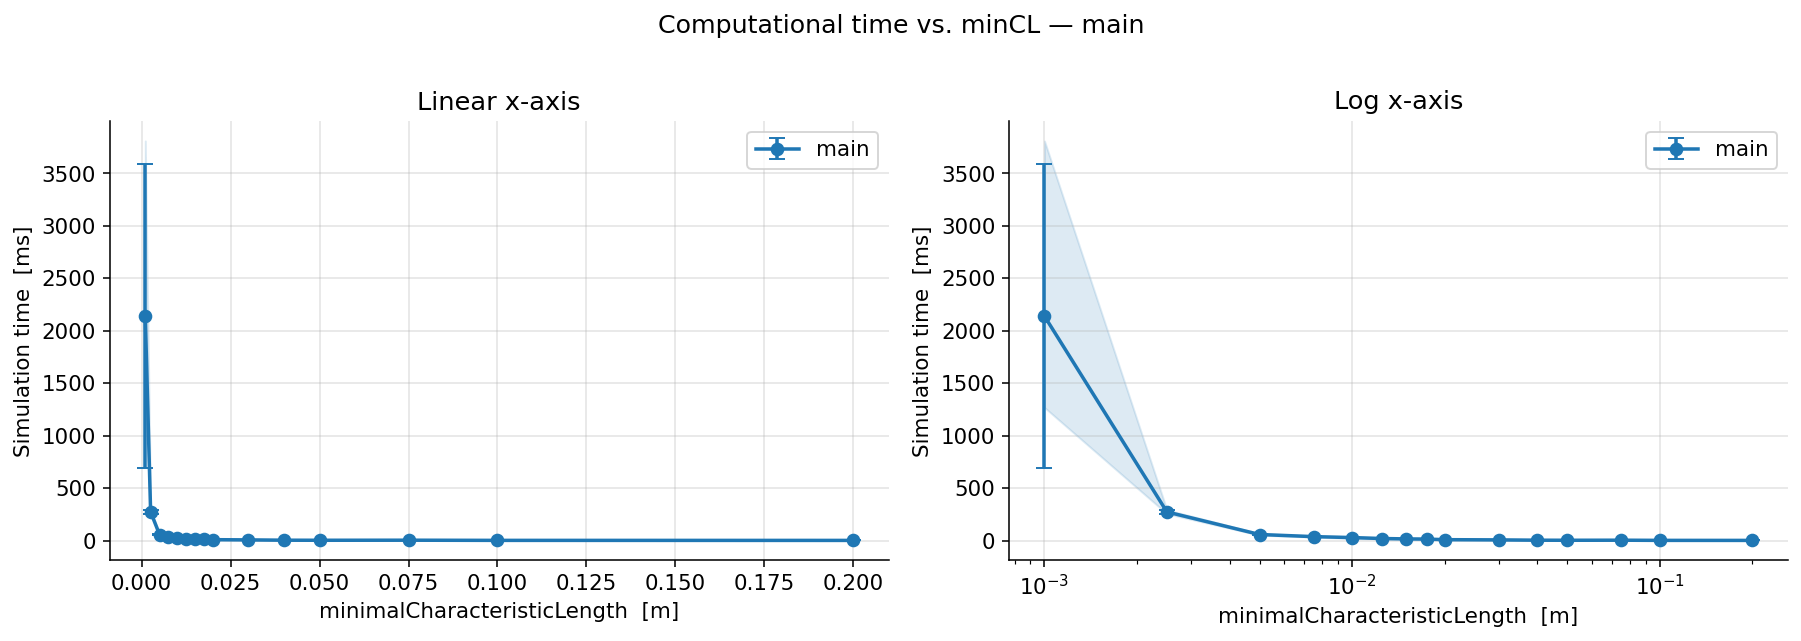

In [8]:
def plot_single(df: pd.DataFrame, color: str = COLOR_A) -> plt.Figure:
    label = df["label"].iloc[0]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for ax, xscale, title in zip(
        axes,
        ["linear", "log"],
        ["Linear x-axis", "Log x-axis"],
    ):
        ax.errorbar(
            df["min_cl"], df["mean_ms"],
            yerr=df["std_ms"],
            fmt="o-", color=color, capsize=4,
            linewidth=1.8, markersize=6, label=label,
        )
        ax.fill_between(
            df["min_cl"], df["min_ms"], df["max_ms"],
            alpha=0.15, color=color,
        )
        ax.set_xscale(xscale)
        ax.set_xlabel("minimalCharacteristicLength  [m]")
        ax.set_ylabel("Simulation time  [ms]")
        ax.set_title(title)
        ax.legend()

    fig.suptitle(f"Computational time vs. minCL — {label}", fontsize=13, y=1.01)
    plt.tight_layout()
    return fig


if df_a is not None:
    fig = plot_single(df_a)
    save_fig(fig, "single_branch_A.png")
    plt.show()

  Saved → plots/single_branch_B.png


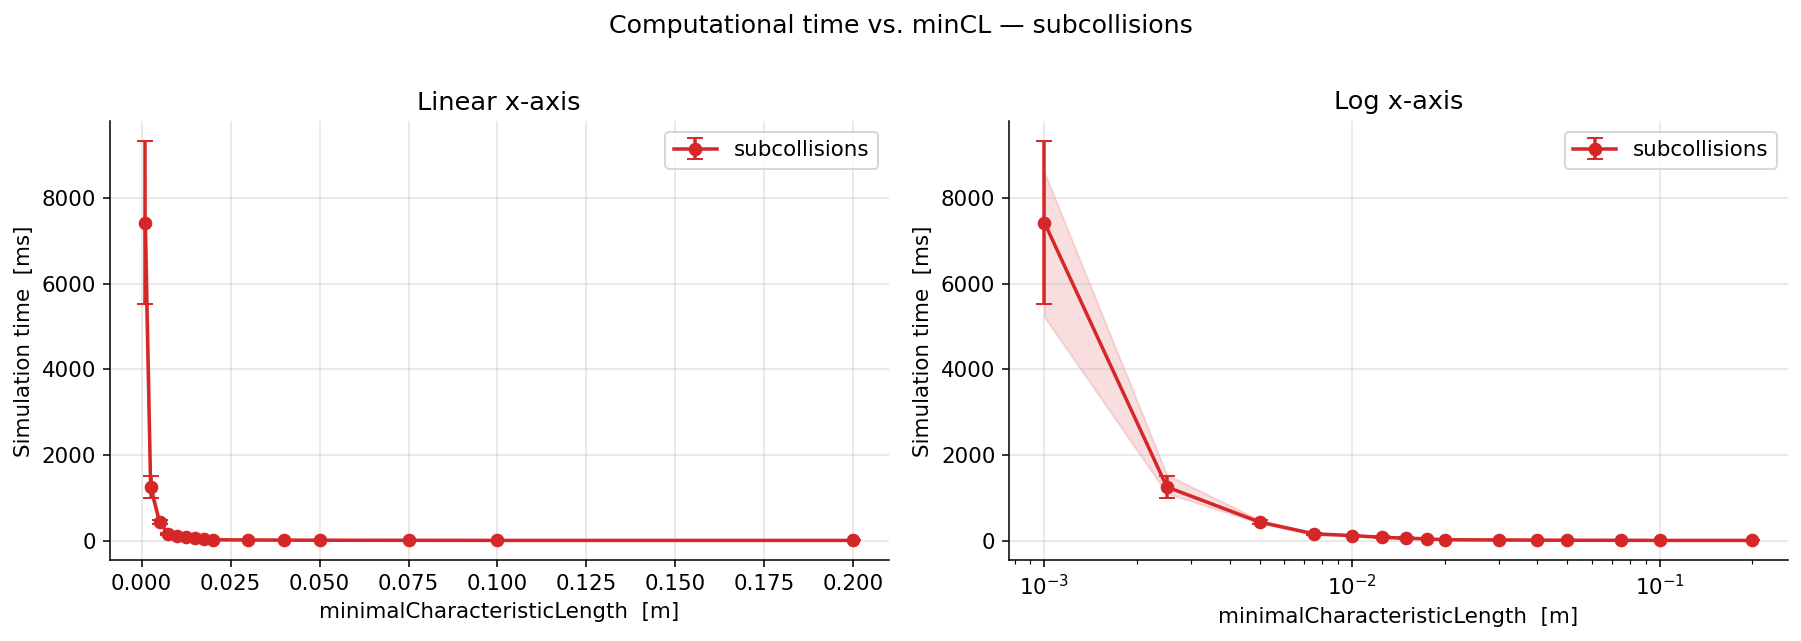

In [9]:
# Do the same but just for the second branch
if df_b is not None:
    fig = plot_single(df_b, color=COLOR_B)
    save_fig(fig, "single_branch_B.png")
    plt.show()

  Saved → plots/single_branch_A_no_outlier.png


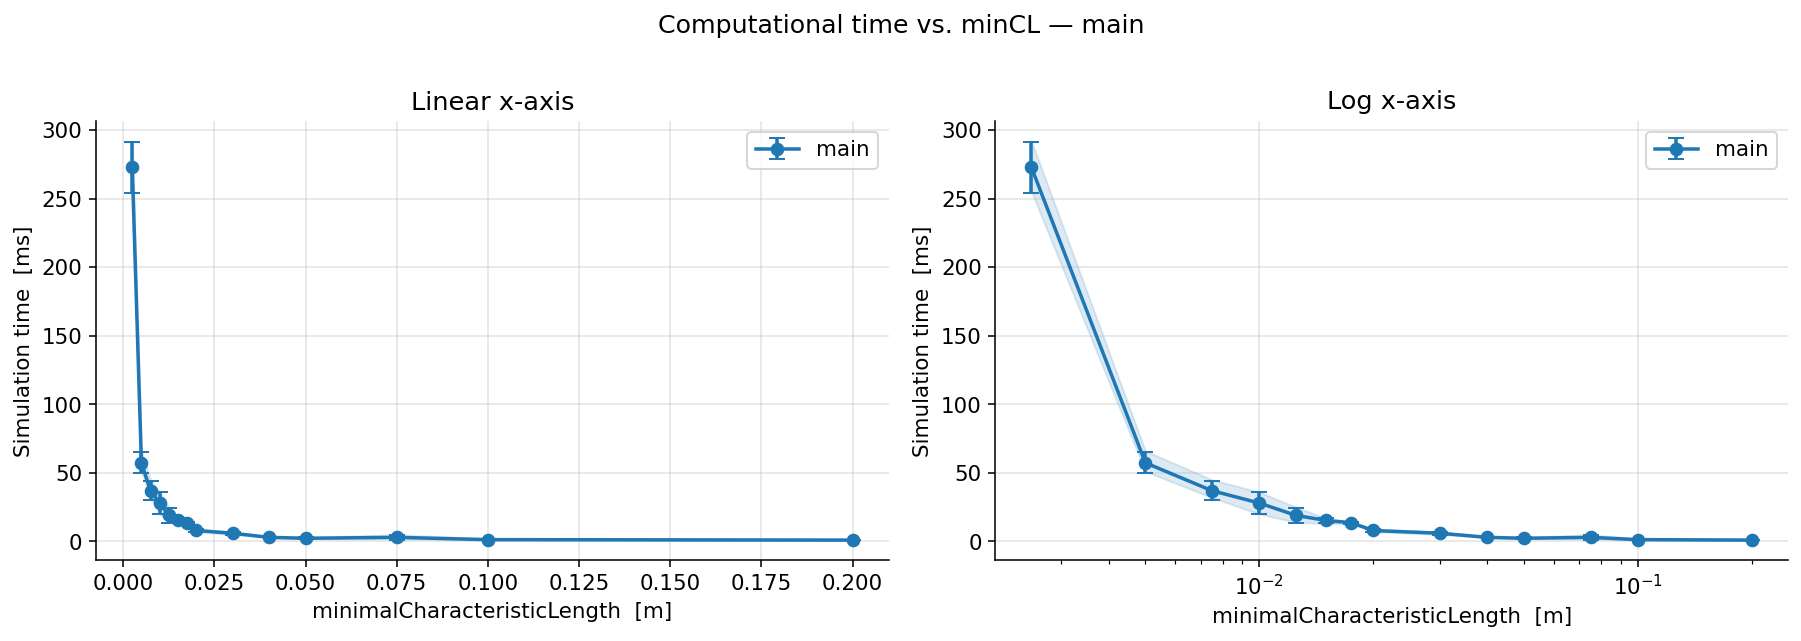

In [10]:
# Do the same but excluding the first point (which is often an outlier)
if df_a is not None and len(df_a) > 1:
    fig = plot_single(df_a.iloc[1:], color=COLOR_A)
    save_fig(fig, "single_branch_A_no_outlier.png")
    plt.show()

  Saved → plots/single_branch_B_no_outlier.png


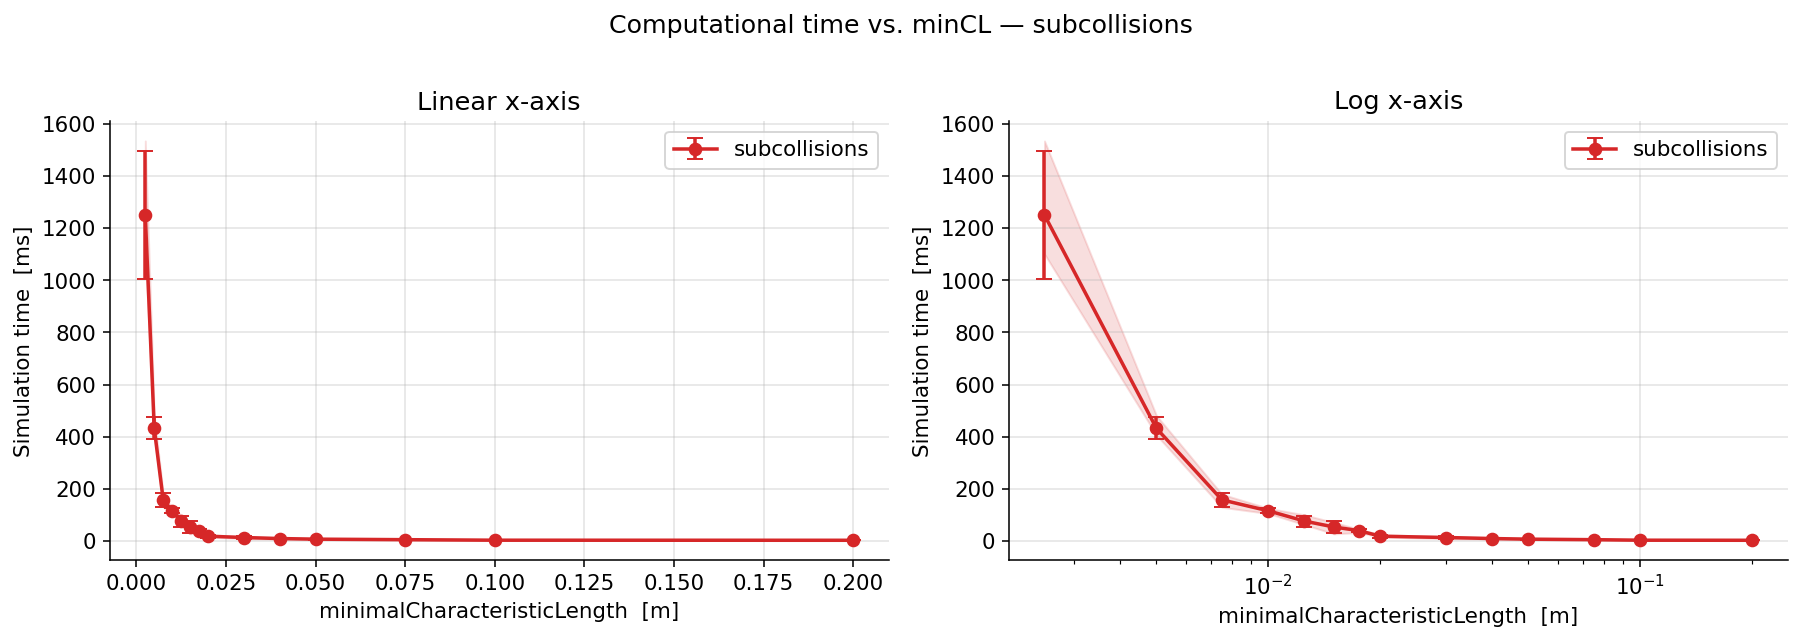

In [11]:
# Same for the second branch
if df_b is not None and len(df_b) > 1:
    fig = plot_single(df_b.iloc[1:], color=COLOR_B)
    save_fig(fig, "single_branch_B_no_outlier.png")
    plt.show()

## 4 — Single-branch: fragments vs. minCL

  Saved → plots/fragments_branch_A.png


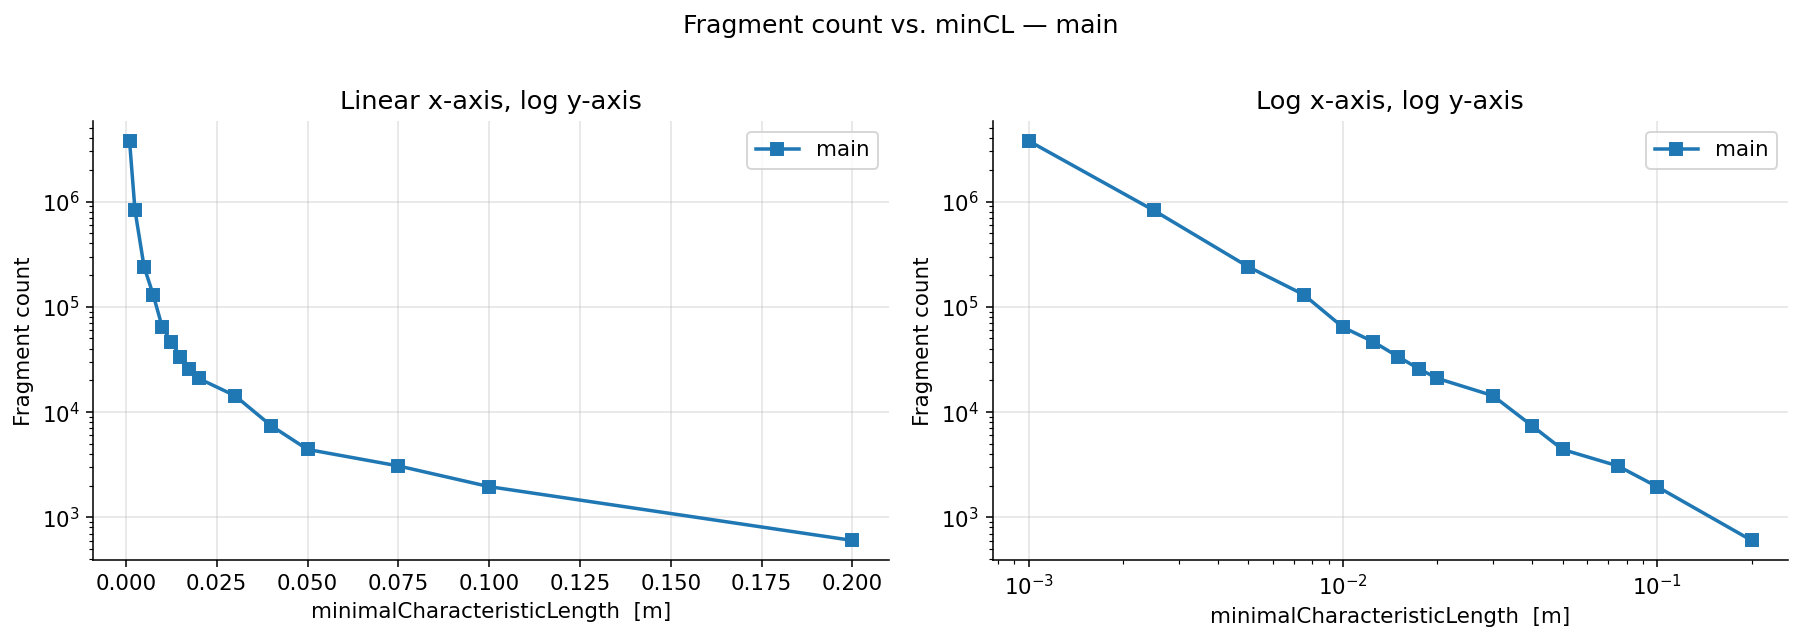

In [12]:
def plot_fragments(df: pd.DataFrame, color: str = COLOR_A) -> plt.Figure:
    label = df["label"].iloc[0]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    for ax, xscale in zip(axes, ["linear", "log"]):
        ax.plot(
            df["min_cl"], df["fragments"],
            "s-", color=color, linewidth=1.8, markersize=6, label=label,
        )
        ax.set_xscale(xscale)
        ax.set_yscale("log")
        ax.set_xlabel("minimalCharacteristicLength  [m]")
        ax.set_ylabel("Fragment count")
        ax.set_title(f"{'Linear' if xscale == 'linear' else 'Log'} x-axis, log y-axis")
        ax.legend()

    fig.suptitle(f"Fragment count vs. minCL — {label}", fontsize=13, y=1.01)
    plt.tight_layout()
    return fig


if df_a is not None:
    fig = plot_fragments(df_a)
    save_fig(fig, "fragments_branch_A.png")
    plt.show()

  Saved → plots/single_branch_B.png


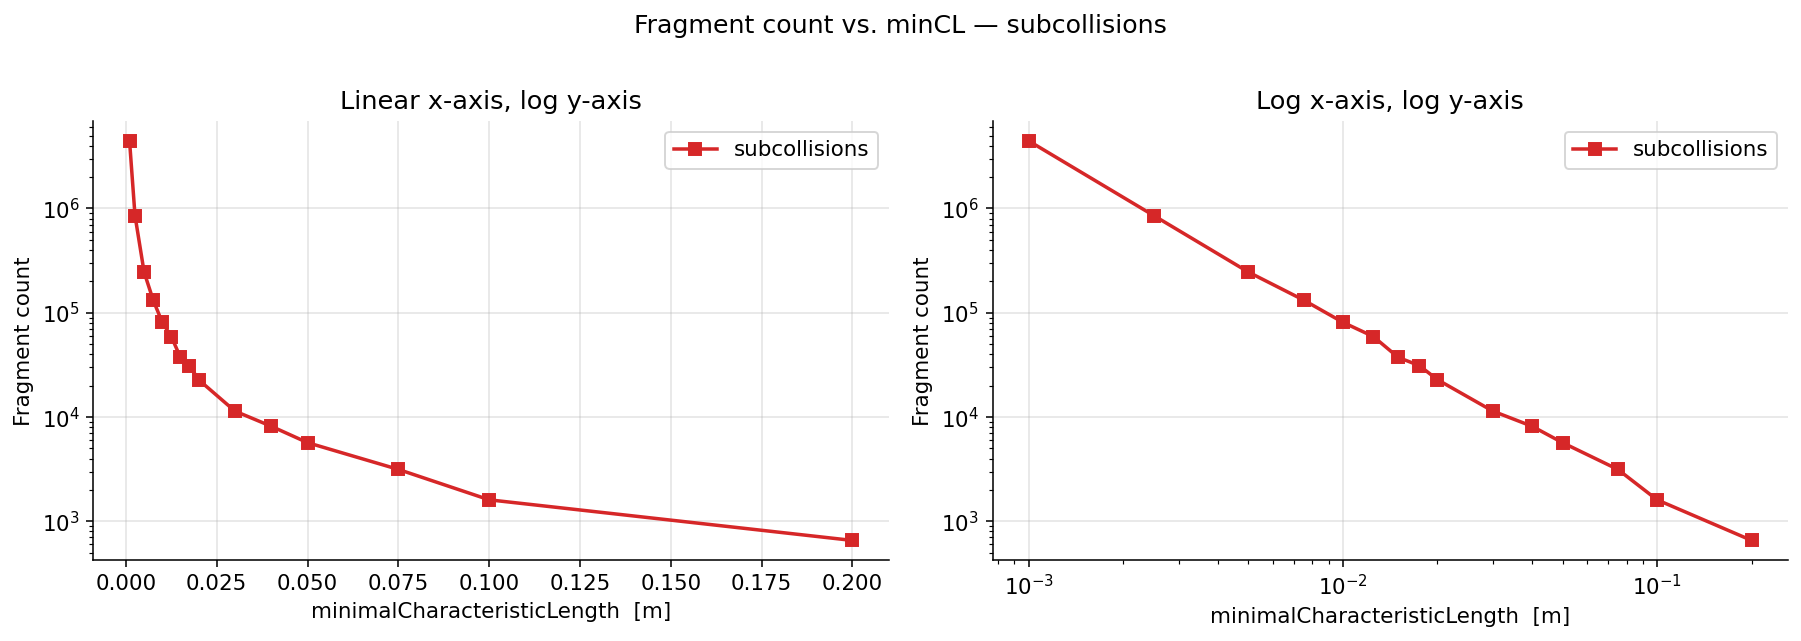

In [14]:
# Do the same but just for the second branch
if df_b is not None:
    fig = plot_fragments(df_b, color=COLOR_B)
    save_fig(fig, "single_branch_B.png")
    plt.show()

## 5 — Time vs. fragment count (efficiency curve)

  Saved → plots/efficiency_branch_A.png


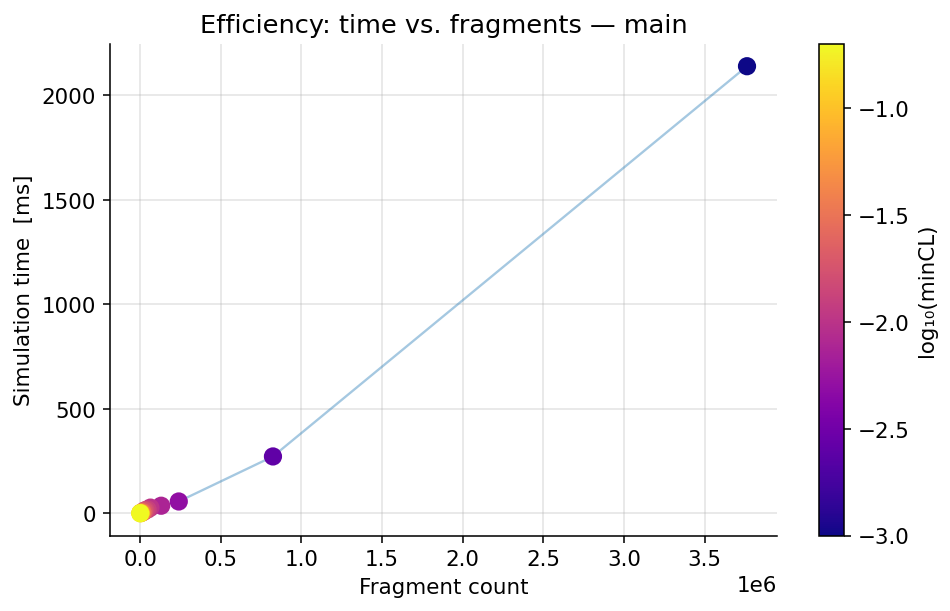

In [15]:
def plot_time_vs_frags(df: pd.DataFrame, color: str = COLOR_A) -> plt.Figure:
    label = df["label"].iloc[0]
    fig, ax = plt.subplots(figsize=(7, 4.5))

    sc = ax.scatter(
        df["fragments"], df["mean_ms"],
        c=np.log10(df["min_cl"]),
        cmap="plasma", s=70, zorder=3,
    )
    ax.plot(df["fragments"], df["mean_ms"],
            "-", color=color, alpha=0.4, linewidth=1.2)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("log₁₀(minCL)")

    ax.set_xlabel("Fragment count")
    ax.set_ylabel("Simulation time  [ms]")
    ax.set_title(f"Efficiency: time vs. fragments — {label}")
    plt.tight_layout()
    return fig


if df_a is not None and df_a["fragments"].notna().any():
    fig = plot_time_vs_frags(df_a)
    save_fig(fig, "efficiency_branch_A.png")
    plt.show()

---
## 6 — Cross-branch comparison

Requires both `CSV_A` and `CSV_B` to be available.

  Saved → plots/comparison_time.png


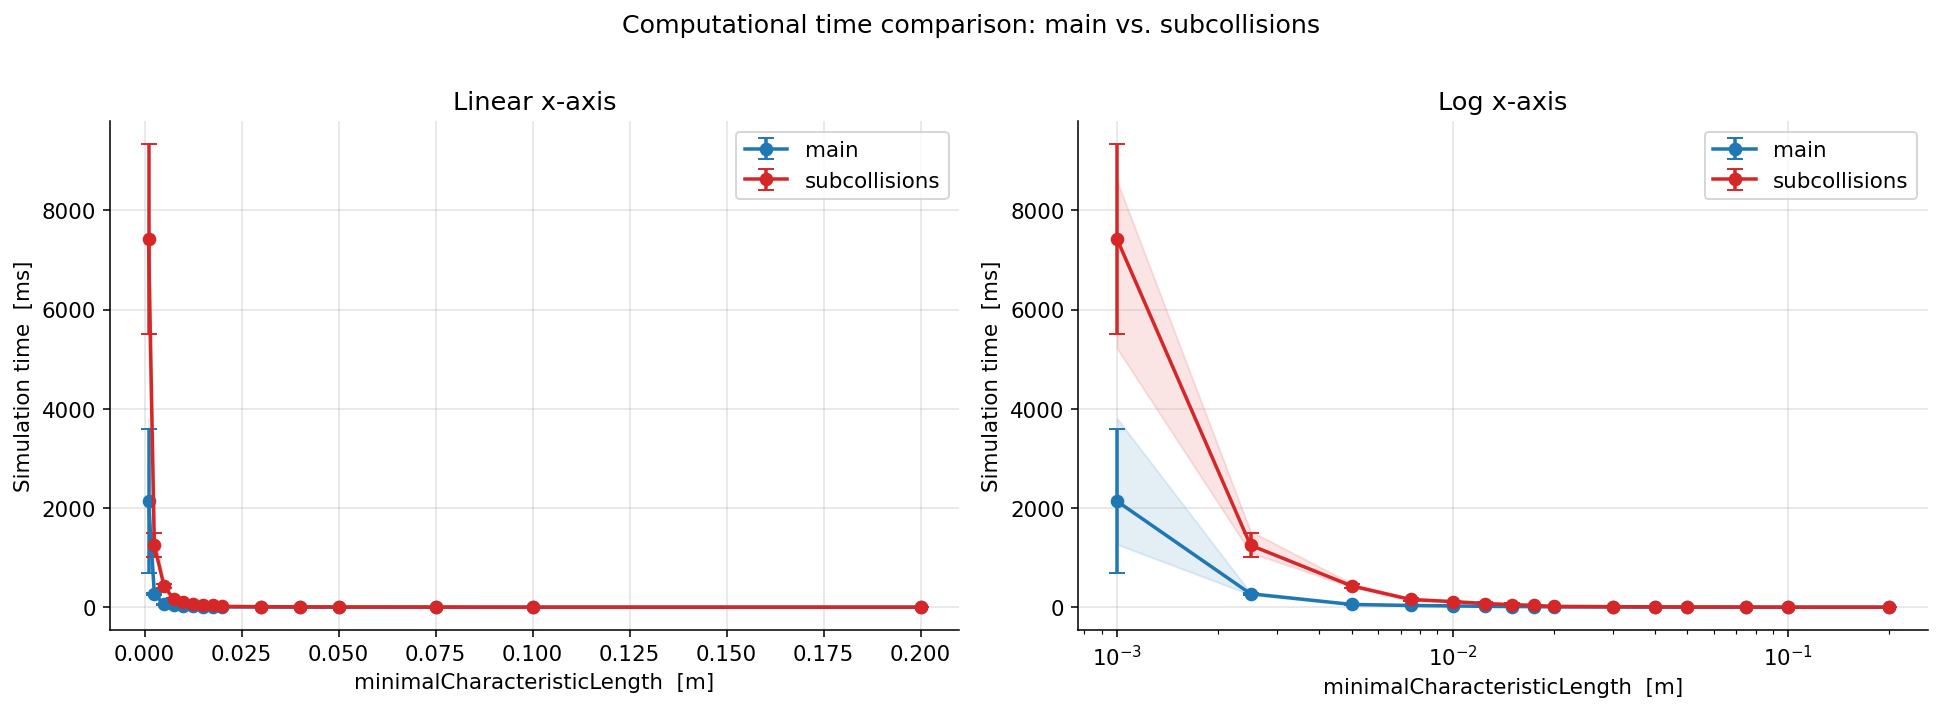

In [16]:
def plot_comparison_time(df_a: pd.DataFrame, df_b: pd.DataFrame) -> plt.Figure:
    label_a = df_a["label"].iloc[0]
    label_b = df_b["label"].iloc[0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, xscale in zip(axes, ["linear", "log"]):
        for df, color, label in [
            (df_a, COLOR_A, label_a),
            (df_b, COLOR_B, label_b),
        ]:
            ax.errorbar(
                df["min_cl"], df["mean_ms"],
                yerr=df["std_ms"],
                fmt="o-", color=color, capsize=4,
                linewidth=1.8, markersize=6, label=label,
            )
            ax.fill_between(
                df["min_cl"], df["min_ms"], df["max_ms"],
                alpha=0.12, color=color,
            )
        ax.set_xscale(xscale)
        ax.set_xlabel("minimalCharacteristicLength  [m]")
        ax.set_ylabel("Simulation time  [ms]")
        ax.set_title(f"{'Linear' if xscale == 'linear' else 'Log'} x-axis")
        ax.legend()

    fig.suptitle(f"Computational time comparison: {label_a} vs. {label_b}",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    return fig


if df_a is not None and df_b is not None:
    fig = plot_comparison_time(df_a, df_b)
    save_fig(fig, "comparison_time.png")
    plt.show()
else:
    print("Skipping comparison plot (need both CSV_A and CSV_B).")

  Saved → plots/comparison_time_no_outliers.png


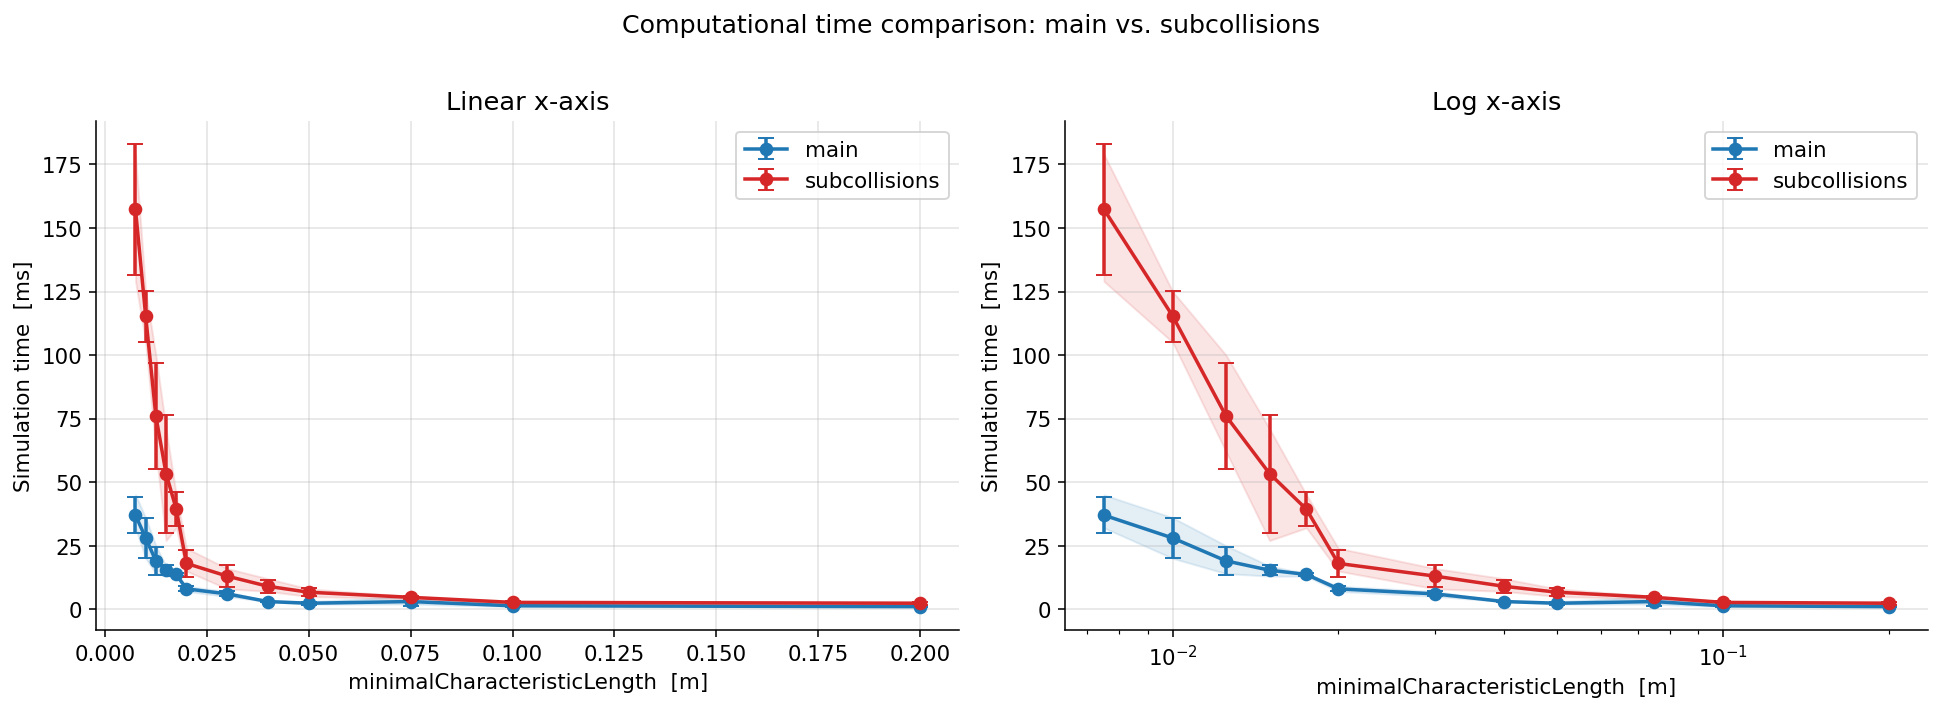

In [17]:
# Exclude the first 3 points (which are often outliers)
if df_a is not None and len(df_a) > 3 and df_b is not None and len(df_b) > 3:
    fig = plot_comparison_time(df_a.iloc[3:], df_b.iloc[3:])
    save_fig(fig, "comparison_time_no_outliers.png")
    plt.show()
else:
    print("Skipping comparison plot without outliers (need at least 4 points in both).")

  Saved → plots/comparison_speedup.png


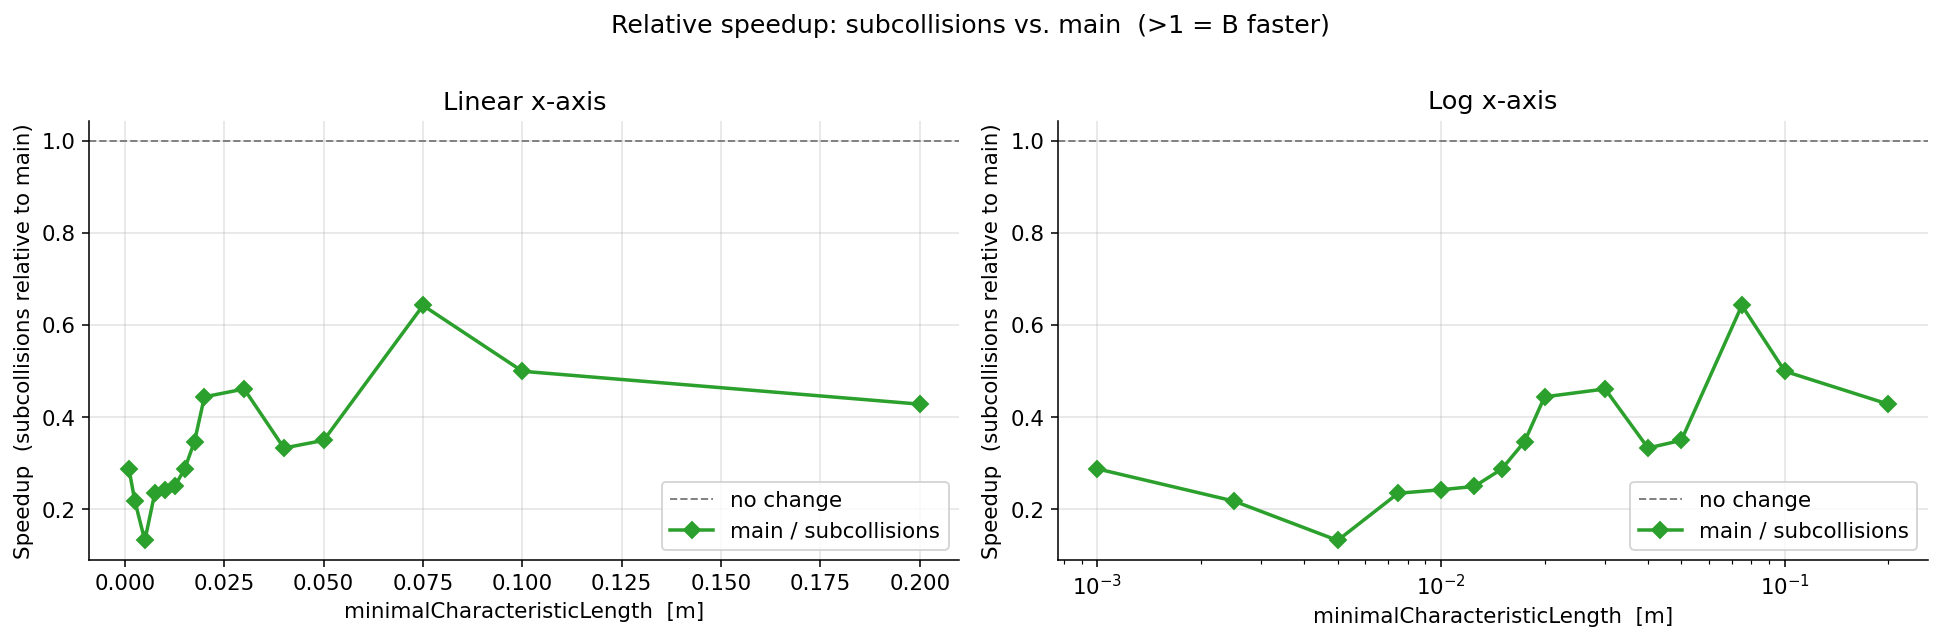

In [ ]:
def plot_speedup(df_a: pd.DataFrame, df_b: pd.DataFrame) -> plt.Figure:
    """Speedup of branch_B relative to branch_A (>1 means B is faster)."""
    label_a = df_a["label"].iloc[0]
    label_b = df_b["label"].iloc[0]

    # Align on shared minCL values
    merged = pd.merge(
        df_a[["min_cl", "mean_ms"]].rename(columns={"mean_ms": "ms_a"}),
        df_b[["min_cl", "mean_ms"]].rename(columns={"mean_ms": "ms_b"}),
        on="min_cl",
    )
    merged["speedup"] = merged["ms_a"] / merged["ms_b"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    for ax, xscale in zip(axes, ["linear", "log"]):
        ax.axhline(1.0, color="grey", linestyle="--", linewidth=1, label="no change")
        ax.plot(
            merged["min_cl"], merged["speedup"],
            "D-", color="#2ca02c", linewidth=1.8, markersize=6,
            label=f"{label_a} / {label_b}",
        )
        ax.set_xscale(xscale)
        ax.set_xlabel("minimalCharacteristicLength  [m]")
        ax.set_ylabel(f"Speedup  ({label_b} relative to {label_a})")
        ax.set_title(f"{'Linear' if xscale == 'linear' else 'Log'} x-axis")
        ax.legend()

    fig.suptitle(f"Relative speedup: {label_b} vs. {label_a}  (>1 = B faster)",
                 fontsize=13, y=1.01)
    plt.tight_layout()
    return fig

if df_a is not None and df_b is not None:
    fig = plot_speedup(df_a, df_b)
    save_fig(fig, "comparison_speedup.png")
    plt.show()
else:
    print("Skipping speedup plot (need both CSV_A and CSV_B).")

  Saved → plots/comparison_time_ratio.png


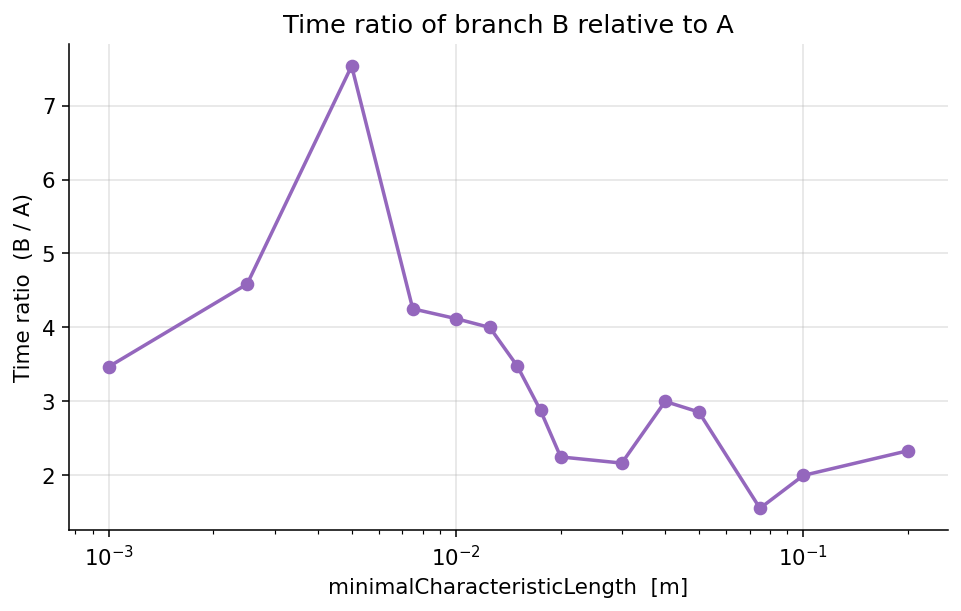

In [19]:
# Time of branch B / time of branch A
if df_a is not None and df_b is not None:
    merged = pd.merge(
        df_a[["min_cl", "mean_ms"]].rename(columns={"mean_ms": "ms_a"}),
        df_b[["min_cl", "mean_ms"]].rename(columns={"mean_ms": "ms_b"}),
        on="min_cl",
    )
    merged["time_ratio"] = merged["ms_b"] / merged["ms_a"]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(
        merged["min_cl"], merged["time_ratio"],
        "o-", color="#9467bd", linewidth=1.8, markersize=6,
    )
    ax.set_xscale("log")
    ax.set_xlabel("minimalCharacteristicLength  [m]")
    ax.set_ylabel(f"Time ratio  (B / A)")
    ax.set_title(f"Time ratio of branch B relative to A")
    plt.tight_layout()
    save_fig(fig, "comparison_time_ratio.png")
    plt.show()
else:
    print("Skipping time ratio plot (need both CSV_A and CSV_B).")

  Saved → plots/comparison_fragments.png


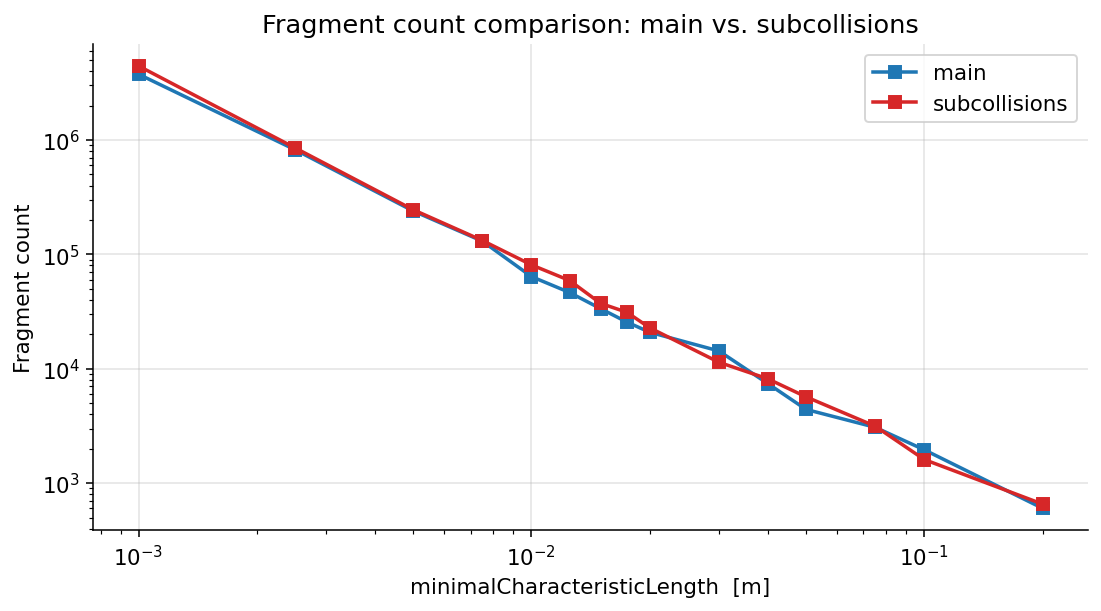

In [20]:
def plot_comparison_fragments(df_a: pd.DataFrame, df_b: pd.DataFrame) -> plt.Figure:
    label_a = df_a["label"].iloc[0]
    label_b = df_b["label"].iloc[0]

    fig, ax = plt.subplots(figsize=(8, 4.5))

    for df, color, label in [
        (df_a, COLOR_A, label_a),
        (df_b, COLOR_B, label_b),
    ]:
        ax.plot(
            df["min_cl"], df["fragments"],
            "s-", color=color, linewidth=1.8,
            markersize=6, label=label,
        )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("minimalCharacteristicLength  [m]")
    ax.set_ylabel("Fragment count")
    ax.set_title(f"Fragment count comparison: {label_a} vs. {label_b}")
    ax.legend()
    plt.tight_layout()
    return fig


if df_a is not None and df_b is not None:
    fig = plot_comparison_fragments(df_a, df_b)
    save_fig(fig, "comparison_fragments.png")
    plt.show()
else:
    print("Skipping fragment comparison plot (need both CSV_A and CSV_B).")

---
## 7 — Summary table

In [21]:
frames = [df for df in [df_a, df_b] if df is not None]
if frames:
    combined = pd.concat(frames, ignore_index=True)
    pivot = combined.pivot_table(
        index="min_cl",
        columns="label",
        values=["mean_ms", "std_ms", "fragments"],
    ).round(1)
    display(pivot)
else:
    print("No data loaded.")

fragments               mean_ms                std_ms              
label       main subcollisions    main subcollisions    main subcollisions
min_cl                                                                    
0.0010   3763486       4442605  2138.7        7423.7  1447.0        1909.8
0.0025    823726        854779   272.7        1250.7    18.6         246.4
0.0050    239607        245677    57.3         432.0     7.8          42.5
0.0075    130430        132208    37.0         157.3     7.0          25.7
0.0100     63933         80943    28.0         115.3     8.0          10.0
0.0125     46450         59107    19.0          76.0     5.6          20.9
0.0150     33506         37285    15.3          53.3     2.1          23.2
0.0175     25581         31145    13.7          39.3     0.6           6.7
0.0200     20846         22794     8.0          18.0     1.0           5.2
0.0300     14303         11395     6.0          13.0     1.0           4.4
0.0400      7397          8152     3.0           9.0     0.0           2.6
0.0500      4407          5675     2.3           6.7     0.6           1.5
0.0750      3073          3143     3.0           4.7     1.7           0.6
0.1000      1953          1606     1.3           2.7     0.6           0.6
0.2000       602           655     1.0           2.3     0.0           0.6